In [3]:
#Deep Source Localizing VML 
import os.path as op
import matplotlib.pyplot as plt
import mne
import numpy as np
from mne import make_forward_solution, setup_source_space, setup_volume_source_space
from mne.minimum_norm import apply_inverse_epochs, make_inverse_operator
from mne.viz import circular_layout
from mne_connectivity import spectral_connectivity_epochs, spectral_connectivity_time
from mne_connectivity.viz import plot_connectivity_circle

In [4]:
s = '003'
path = '/users/mgarson.stu/.anaconda/VML'
meg_path = op.join(path, 'MEG')
mri_path = op.join(path, 'MRI')
sub = f'vml_meg_{s}'
subj = f'vml_mri_{s}'
bem_dir = op.join(mri_path, subj, 'bem')

In [ ]:
meg_data = op.join(meg_path, sub, 'vml_meg_%s_tsss_ica_rot_ave.fif' %s)
meg_data2 = op.join(meg_path, sub, 'vml_meg_%s_tsss_ica_run_ave.fif' %s)

evoked = mne.read_evokeds(meg_data, proj=True, kind='average', verbose=False) #rot 
evoked2 = mne.read_evokeds(meg_data2, proj=True, kind='average', verbose=False) #rot 

erm_raw = op.join(meg_path, sub, 'vml_meg_%s_erm_filtered.fif' %s) #'empty_room_20230717.fif'
erm_data = mne.io.Raw(erm_raw, preload=True, verbose=False)

In [6]:
print(evoked)

[<Evoked | 'right no-rotation' (average, N=12), -0.5 – 1.2 s, baseline -0.5 – -0.3 s, 306 ch, ~10.3 MB>, <Evoked | 'left no-rotation' (average, N=17), -0.5 – 1.2 s, baseline -0.5 – -0.3 s, 306 ch, ~10.3 MB>, <Evoked | 'left rotation' (average, N=34), -0.5 – 1.2 s, baseline -0.5 – -0.3 s, 306 ch, ~10.3 MB>, <Evoked | 'right rotation' (average, N=27), -0.5 – 1.2 s, baseline -0.5 – -0.3 s, 306 ch, ~10.3 MB>]


In [13]:
fname_aseg = op.join(mri_path, subj, 'mri', 'aseg.mgz')
fname_model = op.join(bem_dir, f"{subj}-bem-model.fif")
fname_bem = op.join(bem_dir, f"{subj}-bem-sol.fif")

fname_raw = op.join(meg_path, sub, f"{sub}_1_raw.fif")
fname_trans = op.join(meg_path, sub, f'{sub}-trans.fif')
fname_cov = op.join(meg_path, sub, f'{s}_noise-cov.fif')

In [7]:
labels_vol = [ 
    'Right-Cerebellum-Cortex',
    'Right-Cerebellum-White-Matter',
    'Left-Cerebellum-Cortex',
    'Left-Cerebellum-White-Matter', 
]

In [8]:
src = mne.setup_source_space(subj, spacing="ico5", add_dist="patch", 
                             subjects_dir=mri_path, verbose=False)

Creating the BEM geometry...
Going from 5th to 5th subdivision of an icosahedron (n_tri: 20480 -> 20480)
inner skull CM is  -0.42 -16.09  12.78 mm
Surfaces passed the basic topology checks.
Complete.

Homogeneous model surface loaded.
Computing the linear collocation solution...
    Matrix coefficients...
        inner skull (10242) -> inner skull (10242) ...
    Inverting the coefficient matrix...
Solution ready.
BEM geometry computations complete.
Using surface: c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_026\bem\inner_skull.surf
Using surface: c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_026\bem\outer_skull.surf
Using surface: c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_026\bem\outer_skin.surf


c:\Users\mgarson.stu\AppData\Local\anaconda3\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


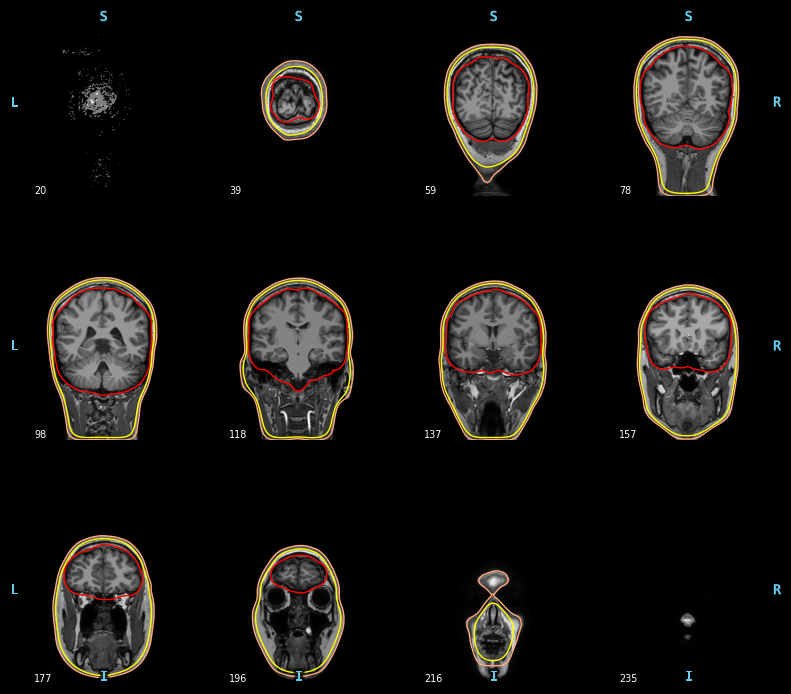

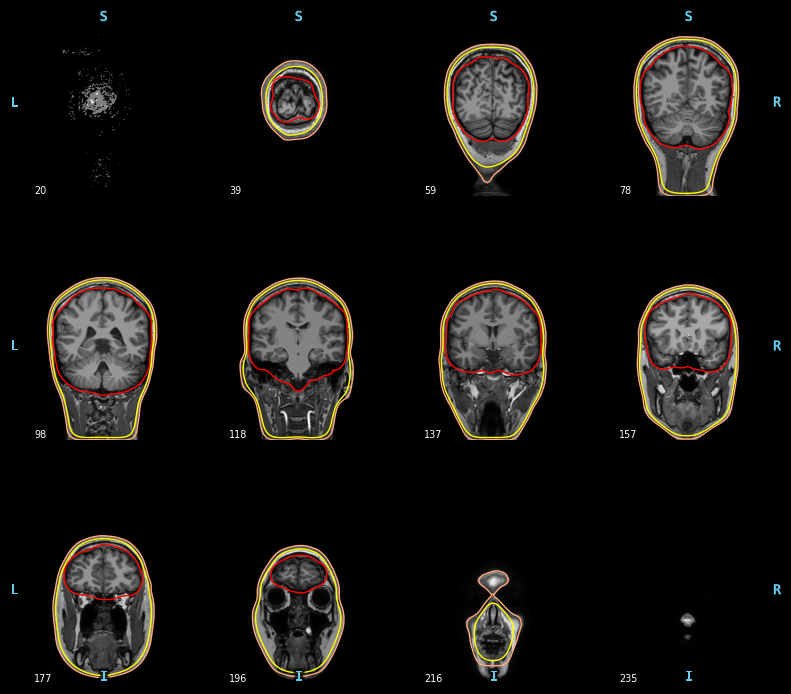

In [9]:
# make boundary element model (BEM) model & solution 
model = mne.make_bem_model(subject=subj, ico=5, conductivity=(0.3,),
                           subjects_dir=mri_path)

bem_sol = mne.make_bem_solution(model)

#Write BEM model file
mne.write_bem_surfaces(op.join(mri_path, subj, 'bem', f'{subj}-bem-model.fif'), model, overwrite=True)

# save bem solution file
mne.write_bem_solution(op.join(mri_path, subj, 'bem', f'{subj}-bem-sol.fif'), bem_sol, overwrite=True)

# plot bem
mne.viz.plot_bem(subject=subj, subjects_dir=mri_path)

In [ ]:
#Setup a Volume Source Space 
vol_src = setup_volume_source_space(
    subj,
    mri = fname_aseg,
    pos = 5.0,
    bem = fname_model, 
    add_interpolator = True,
    volume_label = labels_vol,
    subjects_dir = mri_path
)

#Add volume of DS strucures onto the normal src
src += vol_src

BEM              : c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_026\bem\vml_mri_026-bem-model.fif
grid                  : 5.0 mm
mindist               : 5.0 mm
MRI volume            : /users/mgarson.stu/.anaconda/VML\MRI\vml_mri_026\mri\aseg.mgz

Reading /users/mgarson.stu/.anaconda/VML\MRI\vml_mri_026\mri\aseg.mgz...

Loaded inner skull from c:\users\mgarson.stu\.anaconda\VML\MRI\vml_mri_026\bem\vml_mri_026-bem-model.fif (10242 nodes)
Surface CM = (  -0.4  -16.1   12.8) mm
Surface fits inside a sphere with radius   98.2 mm
Surface extent:
    x =  -68.8 ...   68.6 mm
    y =  -97.9 ...   80.8 mm
    z =  -66.9 ...   81.8 mm
Grid extent:
    x =  -70.0 ...   70.0 mm
    y = -100.0 ...   85.0 mm
    z =  -70.0 ...   85.0 mm
35264 sources before omitting any.
26810 sources after omitting infeasible sources not within 0.0 - 98.2 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    5.0 mm away (will take a few...)
Checking surface int

In [11]:
#Visualize mixed source space within the head model
print(src)
print(vol_src) 
src.plot(src, subjects_dir=mri_path)

<SourceSpaces: [<surface (lh), n_vertices=139304, n_used=10242>, <surface (rh), n_vertices=138869, n_used=10242>, <volume (Right-Cerebellum-Cortex), n_used=484>, <volume (Right-Cerebellum-White-Matter), n_used=132>, <volume (Left-Cerebellum-Cortex), n_used=459>, <volume (Left-Cerebellum-White-Matter), n_used=143>] MRI (surface RAS) coords, subject 'vml_mri_026', ~299.3 MB>
<SourceSpaces: [<volume (Right-Cerebellum-Cortex), n_used=484>, <volume (Right-Cerebellum-White-Matter), n_used=132>, <volume (Left-Cerebellum-Cortex), n_used=459>, <volume (Left-Cerebellum-White-Matter), n_used=143>] MRI (surface RAS) coords, subject 'vml_mri_026', ~271.8 MB>
Using pyvistaqt 3d backend.
Using outer_skin.surf for head surface.


In [28]:
#Read in noise covariance matrix from ERM data
noise_cov = mne.read_cov(fname_cov)

    306 x 306 full covariance (kind = 1) found.


In [ ]:
# compute the fwd matrix
fwd = make_forward_solution(evoked[0].info, fname_trans, src, fname_bem)
fwd2 = make_forward_solution(evoked2[0].info, fname_trans, src, fname_bem)

#Save forward solutions computed on mixed source space. Note you don't need two this was from Alex's *legacy* code
mne.write_forward_solution(op.join(meg_path, sub,  f'{s}-cerebellar-fw-solution-rot.fif'), fwd, overwrite=True)
mne.write_forward_solution(op.join(meg_path, sub,  f'{s}-cerebellar-fw-solution-run.fif'), fwd2, overwrite=True)

Source space          : <SourceSpaces: [<surface (lh), n_vertices=139304, n_used=10242>, <surface (rh), n_vertices=138869, n_used=10242>, <volume (Right-Cerebellum-Cortex), n_used=484>, <volume (Right-Cerebellum-White-Matter), n_used=132>, <volume (Left-Cerebellum-Cortex), n_used=459>, <volume (Left-Cerebellum-White-Matter), n_used=143>] MRI (surface RAS) coords, subject 'vml_mri_026', ~299.3 MB>
MRI -> head transform : \users\mgarson.stu\.anaconda\VML\MEG\vml_meg_026\vml_meg_026-trans.fif
Measurement data      : instance of Info
Conductor model   : /users/mgarson.stu/.anaconda/VML\MRI\vml_mri_026\bem\vml_mri_026-bem-sol.fif
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 6 source spaces a total of 21702 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.998242 -0.006027 -0.058954       0.94 mm
    0.029919 0.909974 0.413585      19.10 mm
    0.051154 -0.414622 0.908555      46.62 mm
    0.000000 0.000000 0

C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_31148\3200923954.py:6: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_026\026-cerebellar-fw-solution-rot.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  mne.write_forward_solution(op.join(meg_path, sub,  f'{s}-cerebellar-fw-solution-rot.fif'), fwd, overwrite=True)


    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    6 source spaces written
    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    Write a source space...


C:\Users\mgarson.stu\AppData\Local\Temp\ipykernel_31148\3200923954.py:7: RuntimeWarning: This filename (/users/mgarson.stu/.anaconda/VML\MEG\vml_meg_026\026-cerebellar-fw-solution-run.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  mne.write_forward_solution(op.join(meg_path, sub,  f'{s}-cerebellar-fw-solution-run.fif'), fwd2, overwrite=True)


    [done]
    Write a source space...
    [done]
    Write a source space...
    [done]
    6 source spaces written


In [30]:
# Compute the rank for the noise covariance
rank_cov = mne.compute_rank(noise_cov, info=erm_data.info)
print("Rank of noise covariance:", rank_cov)

Computing rank from covariance with rank=None
    Using tolerance 2.7e-13 (2.2e-16 eps * 306 dim * 4  max singular value)
    Estimated rank (mag + grad): 74
    MEG: rank 74 computed from 306 data channels with 0 projectors
Rank of noise covariance: {'meg': 74}


In [31]:
#Set according to rank_cov
specified_rank = {'meg': 74, 'eeg': 0}

In [32]:
#Inverse operator
inv = mne.minimum_norm.make_inverse_operator(evoked[0].info, fwd, noise_cov, rank=specified_rank, verbose=False)
inv2 = mne.minimum_norm.make_inverse_operator(evoked2[0].info, fwd2, noise_cov, rank=specified_rank, verbose=False)

In [ ]:
snr = 3.0
lambda2 = 1.0 / snr ** 2

#Store STCs for later 
stcs = []

#For saving mixed source STC as a .h5 file 
save_stc_file = op.join(meg_path, sub, 'mixed_stc_plots', 'DS-Final' + s + "_")

run_conds = ["Baseline", "Early_Learning", "Late_Learning", "Washout", "Relearning"]
allconds = ['right no-rotation', 'left no-rotation', 'right rotation', 'left rotation'] 

for x in range (0,len(allconds)): # 4 conditions 
	# The sources are computed using dSPM method and plotted on an inflated brain surface. For interactive controls over the image, use keyword time_viewer=True
	stc = mne.minimum_norm.apply_inverse(evoked[x], inv, lambda2, 'dSPM', pick_ori=None) #pick_ori='vector' for vector source estimate
	stcs.append(stc) 
	stc.save(save_stc_file + 'cond-' + allconds[x], overwrite=True);

	brain = stc.plot(subjects_dir=mri_path, 
				  	subject=subj, 
				  	src=src, 
					time_viewer= True, 
				  	surface="white",  
					hemi='both', 
					time_unit='s', 
					smoothing_steps=7, 
					brain_kwargs=dict(title=allconds[x])); 
	
	#Label the subcortical regions 
	# brain.add_volume_labels(aseg='aparc+aseg', 
	# 					 	labels=['Left-Cerebellum-Cortex', 
	# 								'Left-Cerebellum-White-Matter', 
	# 								'Right-Cerebellum-Cortex', 
	# 								'Right-Cerebellum-White-Matter'],
	# 					 	colors=None, 
	# 						alpha=0.5, 
	# 						smooth=0.9, 
	# 						fill_hole_size=True, 
	# 						legend=True)
	
	brain.add_text(text=f'{allconds[x]}', x=0.2, y=0.9, font_size=20, color='white')
	
	brain.clear_glyphs()


	del stc

#Run conditions 
 
for x in range (0,len(run_conds)): # 4 conditions 
	# The sources are computed using dSPM method and plotted on an inflated brain surface. For interactive controls over the image, use keyword time_viewer=True
	stc = mne.minimum_norm.apply_inverse(evoked2[x], inv, lambda2, 'dSPM', pick_ori=None) #pick_ori='vector' for vector source estimate
	stc.save(save_stc_file + 'cond-' + run_conds[x], overwrite=True);

	brain = stc.plot(subjects_dir=mri_path, 
				  	subject=subj, 
				  	src=src, 
					time_viewer= True, 
				  	surface="white",  
					hemi='both', 
					time_unit='s', 
					smoothing_steps=7, 
					brain_kwargs=dict(title=run_conds[x])); 
	
	#Label the subcortical regions 
	# brain.add_volume_labels(aseg='aparc+aseg', 
	# 					 	labels=['Left-Cerebellum-Cortex', 
	# 								'Left-Cerebellum-White-Matter', 
	# 								'Right-Cerebellum-Cortex', 
	# 								'Right-Cerebellum-White-Matter'],
	# 					 	colors=None, 
	# 						alpha=0.5, 
	# 						smooth=0.9, 
	# 						fill_hole_size=True, 
	# 						legend=True)
	
	brain.add_text(text=f'{run_conds[x]}', x=0.2, y=0.9, font_size=20, color='white')
	
	brain.clear_glyphs()


	del stc

NameError: name 'inv' is not defined

The rest of this code was for figuring out how to extract time courses from the cerebellum 

In [145]:
full_stcs = stcs.copy() 
print(full_stcs)


[<MixedSourceEstimate | 21478 vertices, subject : vml_mri_011, tmin : -500.0 (ms), tmax : 1200.0 (ms), tstep : 1.0 (ms), data shape : (21478, 1701), ~278.9 MB>, <MixedSourceEstimate | 21478 vertices, subject : vml_mri_011, tmin : -500.0 (ms), tmax : 1200.0 (ms), tstep : 1.0 (ms), data shape : (21478, 1701), ~278.9 MB>, <MixedSourceEstimate | 21478 vertices, subject : vml_mri_011, tmin : -500.0 (ms), tmax : 1200.0 (ms), tstep : 1.0 (ms), data shape : (21478, 1701), ~278.9 MB>, <MixedSourceEstimate | 21478 vertices, subject : vml_mri_011, tmin : -500.0 (ms), tmax : 1200.0 (ms), tstep : 1.0 (ms), data shape : (21478, 1701), ~278.9 MB>]
<MixedSourceEstimate | 21478 vertices, subject : vml_mri_011, tmin : -500.0 (ms), tmax : 1200.0 (ms), tstep : 1.0 (ms), data shape : (21478, 1701), ~278.9 MB>


In [59]:
#Read in and compare old stc plots: 
for x in range(len(allconds)): 
	#Right no-rotation
	rh_stc = mne.read_source_estimate(op.join(meg_path, sub, 'old_stc_plots', f'Final{s}_cond-{allconds[x]}-rh.stc'))
	lh_stc = mne.read_source_estimate(op.join(meg_path, sub, 'old_stc_plots', f'Final{s}_cond-{allconds[x]}-lh.stc'))
	stc = rh_stc + lh_stc

	brain = stc.plot(subjects_dir=mri_path, 
						subject=subj, 
						time_viewer= True, 
						surface="white",  
						hemi='both', 
						time_unit='s', 
						smoothing_steps=7, 
						brain_kwargs=dict(title='right no-rotation'))

	brain.add_text(text=f'OLD {allconds[x]} STC', font_size=20, color='white', x=0.2, y=0.9)
	brain.show() 

	del stc

Using control points [ 8.40239212  9.435291   19.82468886]
Using control points [ 8.88300835 10.11480801 24.03517928]
Using control points [ 9.70429237 10.99403183 26.30353558]
Using control points [10.17922726 11.58248036 27.43920104]


In [34]:
plot_labels = mne.get_volume_labels_from_src(src, subj, mri_path)
print(plot_labels)

[<Label | vml_mri_025, 'Cerebellum-Cortex-rh', rh : 382 vertices>, <Label | vml_mri_025, 'Cerebellum-White-Matter-rh', rh : 110 vertices>, <Label | vml_mri_025, 'Cerebellum-Cortex-lh', lh : 373 vertices>, <Label | vml_mri_025, 'Cerebellum-White-Matter-lh', lh : 111 vertices>]


In [39]:
print(src)
print(plot_labels[0])

<SourceSpaces: [<surface (lh), n_vertices=111841, n_used=10242>, <surface (rh), n_vertices=109295, n_used=10242>, <volume (Right-Cerebellum-Cortex), n_used=364>, <volume (Right-Cerebellum-White-Matter), n_used=109>, <volume (Left-Cerebellum-Cortex), n_used=401>, <volume (Left-Cerebellum-White-Matter), n_used=120>] MRI (surface RAS) coords, subject 'vml_mri_011', ~308.5 MB>
<Label | vml_mri_011, 'Cerebellum-Cortex-rh', rh : 364 vertices>


In [42]:
stc = mne.minimum_norm.apply_inverse(evoked[0], inv, lambda2, 'dSPM', pick_ori=None, verbose=False) # Right no-rotation condition
rh_cerebellar_cortex_tc = mne.extract_label_time_course(stc, labels=plot_labels[0], src=src, mode='mean')
print(rh_cerebellar_cortex_tc)

Extracting time courses for 5 labels (mode: mean)
[[1.83209494 2.09712026 2.27124227 ... 2.25550894 2.43627134 2.56938031]
 [1.36507179 1.17326218 1.19413552 ... 1.00452629 1.28327541 1.60252271]
 [1.47203738 1.0428097  0.98650739 ... 1.10153319 1.36604705 1.67170289]
 [1.52836218 1.36198038 1.29013001 ... 1.51220846 1.53817359 1.59637398]
 [1.62243968 1.35203383 1.27248574 ... 1.51250177 1.56116147 1.72938423]]


Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 19
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 74 (232 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "right no-rotation"...
    Picked 306 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  90.9% variance
    Combining the current components...
    dSPM...
[done]
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)
Extracting time courses for 5 labels (mode: mean)
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 18
    Created the regularized inverter
    The projection ve

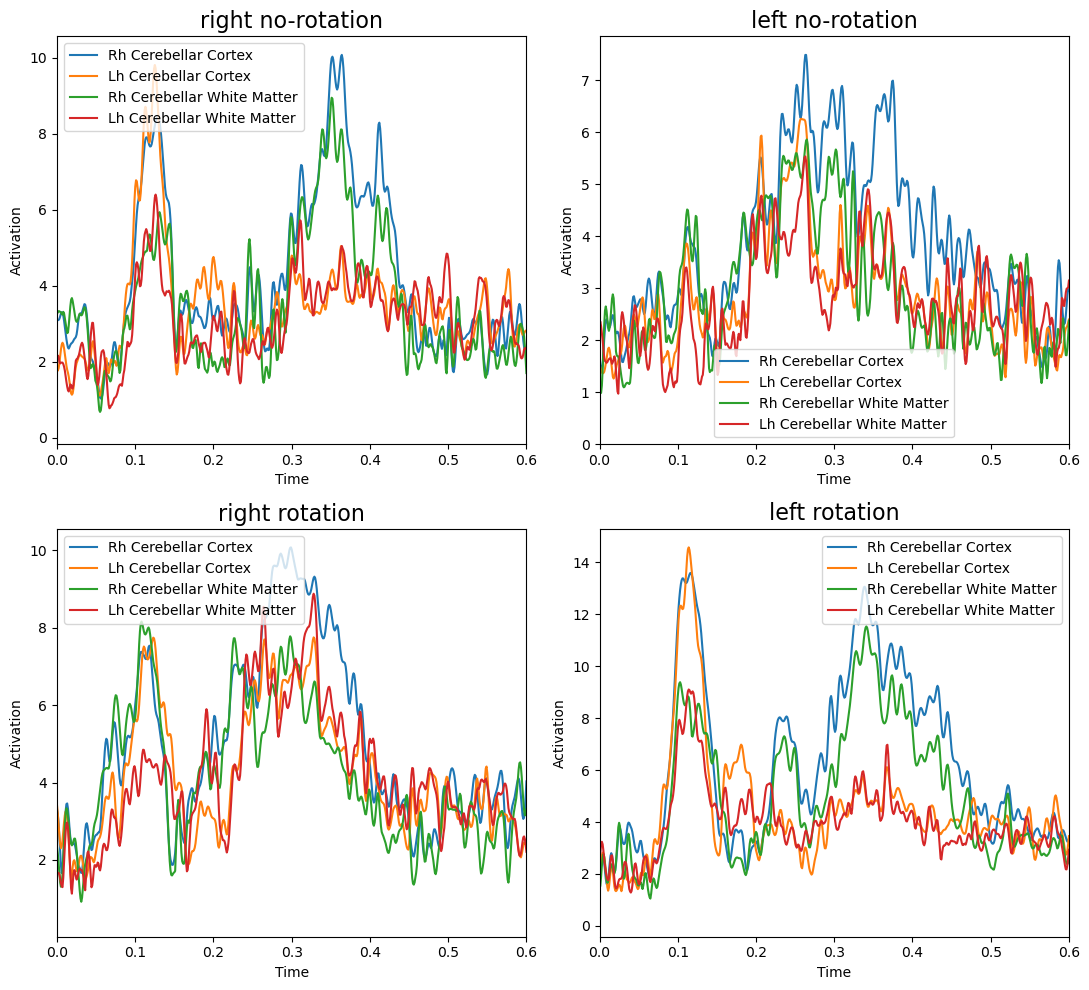

In [36]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

# Flatten the axes array to easily access each subplot
axes = axes.flatten()

for x in range(len(allconds)): 
    stc = mne.minimum_norm.apply_inverse(evoked[x], inv, lambda2, 'dSPM', pick_ori=None) # Right no-rotation condition
    times = stc.times

    # Cerebellum Cortex RH/LH  
    rh_cerebellar_cortex_tc = mne.extract_label_time_course(stc, labels=plot_labels[0], src=src, mode='mean')
    rh_cerebellar_cortex_tc = rh_cerebellar_cortex_tc[0] # Five regions, the last 4 show same timecourse! 
    rh_cerebellar_cortex_mat = np.column_stack((times, rh_cerebellar_cortex_tc))

    lh_cerebellar_cortex_tc = mne.extract_label_time_course(stc, labels=plot_labels[2], src=src, mode='mean')
    lh_cerebellar_cortex_tc = lh_cerebellar_cortex_tc[0]
    lh_cerebellar_cortex_mat = np.column_stack((times, lh_cerebellar_cortex_tc))

    # Cerebellum White Matter RH/LH 
    rh_cerebellar_white_matter_tc = mne.extract_label_time_course(stc, labels=plot_labels[1], src=src, mode='mean')
    rh_cerebellar_white_matter_tc = rh_cerebellar_white_matter_tc[0]
    rh_cerebellar_white_matter_mat = np.column_stack((times, rh_cerebellar_white_matter_tc))

    lh_cerebellar_white_matter_tc = mne.extract_label_time_course(stc, labels=plot_labels[3], src=src, mode='mean')
    lh_cerebellar_white_matter_tc = lh_cerebellar_white_matter_tc[0]
    lh_cerebellar_white_matter_mat = np.column_stack((times, lh_cerebellar_white_matter_tc))

    # Plotting on the respective subplot
    ax = axes[x]
    ax.plot(times, rh_cerebellar_cortex_tc, label='Rh Cerebellar Cortex') 
    ax.plot(times, lh_cerebellar_cortex_tc, label='Lh Cerebellar Cortex') 
    ax.plot(times, rh_cerebellar_white_matter_tc, label='Rh Cerebellar White Matter') 
    ax.plot(times, lh_cerebellar_white_matter_tc, label='Lh Cerebellar White Matter') 
    ax.set_xlabel('Time')
    ax.set_ylabel('Activation') 
    ax.set_xlim(0, 0.6)
    ax.set_title(f'{allconds[x]}', size=16) 
    ax.legend()

    # Save these activation matrices for further analysis 
    # np.save(f'{s}_dSPM_{allconds[x]}_cerebellar_cortex_rh', rh_cerebellar_cortex_mat)
    # np.save(f'{s}_dSPM_{allconds[x]}_cerebellar_cortex_lh', lh_cerebellar_cortex_mat)
    # np.save(f'{s}_dSPM_{allconds[x]}_cerebellar_white_matter_rh', rh_cerebellar_white_matter_mat)
    # np.save(f'{s}_dSPM_{allconds[x]}_cerebellar_white_matter_lh', lh_cerebellar_white_matter_mat)

# Adjust layout to avoid overlapping
plt.tight_layout()

# Show the figure with all subplots
plt.show()


In [202]:
#Generate a connectivity map: 

#Compute Connectivity in the alpha band 
fmin = 12
fmax = 30
sfreq = 1000
#freqs = np.linspace(fmin, fmax, 1)
method = 'pli'
epo = 'right_rotation'

#Apply inverse operator directly to epochs 
epochs = mne.read_epochs(op.join(meg_path, sub, f'{sub}_{epo}-epo.fif')) 
inv = mne.minimum_norm.make_inverse_operator(epochs.info, fwd, noise_cov, rank=specified_rank, verbose=False)

stcs = apply_inverse_epochs(
    epochs, inv, lambda2, 'dSPM', pick_ori=None, return_generator=True
)
labels_parc = mne.read_labels_from_annot(subj, parc='aparc', subjects_dir=mri_path)

label_ts = mne.extract_label_time_course(
    stcs, labels_parc, src, mode="mean_flip", allow_empty=True, return_generator=True
)

con = spectral_connectivity_epochs(
    label_ts,
    method=method,
    mode="multitaper",
    sfreq=sfreq,
    fmin=fmin,
    fmax=fmax,
    faverage=True,
    n_jobs=1,
)


Reading /Users/immlab/Desktop/Deep_Source/MEG/vml_meg_011/vml_meg_011_right_rotation-epo.fif ...
    Found the data of interest:
        t =    -500.00 ...    1200.00 ms
        0 CTF compensation matrices available
Not setting metadata
39 matching events found
No baseline correction applied
0 projection items activated
Reading labels from parcellation...
   read 34 labels from /Users/immlab/Desktop/Deep_Source/MRI/vml_mri_011/label/lh.aparc.annot
   read 34 labels from /Users/immlab/Desktop/Deep_Source/MRI/vml_mri_011/label/rh.aparc.annot
Connectivity computation...
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 74 (232 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Picked 306 channels from the data
Computing inverse...
    Eig

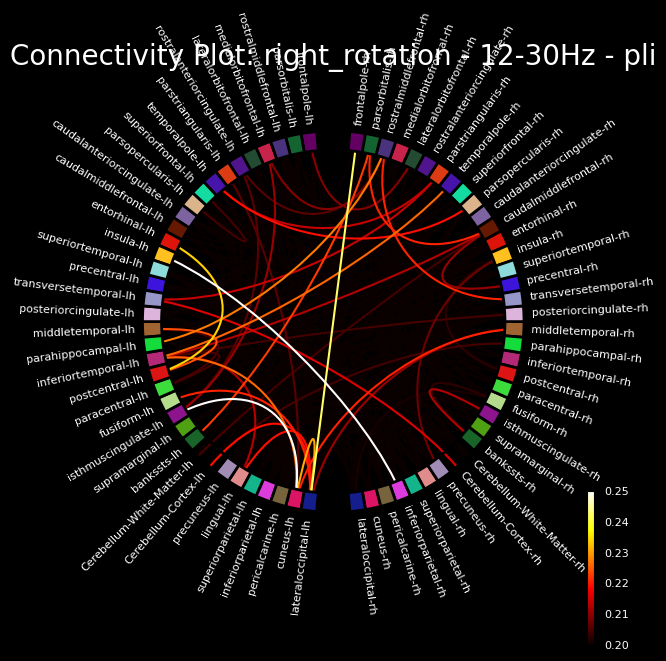

In [234]:
labels_aseg = mne.get_volume_labels_from_src(src, subj, mri_path)
labels = labels_parc + labels_aseg

node_colors = [label.color for label in labels]
# We reorder the labels based on their location in the left hemi
label_names = [label.name for label in labels]
lh_labels = [name for name in label_names if name.endswith("lh")]
rh_labels = [name for name in label_names if name.endswith("rh")]

# Get the y-location of the label
label_ypos_lh = list()
for name in lh_labels:
    idx = label_names.index(name)
    ypos = np.mean(labels[idx].pos[:, 1])
    label_ypos_lh.append(ypos)
try:
    idx = label_names.index("Brain-Stem")
except ValueError:
    pass
else:
    ypos = np.mean(labels[idx].pos[:, 1])
    lh_labels.append("Brain-Stem")
    label_ypos_lh.append(ypos)

lh_labels = [label for (yp, label) in sorted(zip(label_ypos_lh, lh_labels))]

# For the right hemi
rh_labels = [
    label[:-2] + "rh"
    for label in lh_labels
    if label != "Brain-Stem" and label[:-2] + "rh" in rh_labels
]

# Save the plot order
node_order = lh_labels[::-1] + rh_labels

node_angles = circular_layout(
    label_names, node_order, start_pos=90, group_boundaries=[0, len(label_names) // 2]
)

# Plot the graph using node colors from the FreeSurfer parcellation. We only
# show the 300 strongest connections.
conmat = con.get_data(output="dense")[:, :, 0]
fig, ax = plt.subplots(figsize=(8, 10), facecolor="black", subplot_kw=dict(polar=True))
plot_connectivity_circle(
    conmat,
    label_names,
    n_lines=300,
    node_angles=node_angles,
    node_colors=node_colors,
    title=f"Connectivity Plot: {epo} - {fmin}-{fmax}Hz - {method}",
    fontsize_title = 20, 
    padding = 3, 
    ax=ax,
    vmin=0.20,
    vmax=0.25
)


fig.tight_layout()
plt.show()

In [ ]:
#Still to-do to get back to old code standards: 
'''
1) Extract TC activations in all four cerebellar regions and plot them on the same graph over time (DONE) 
2) Bring back the old stc plots for comparison (DONE)
3) Automate saving new STC plots in folder 'mixed_stc_plots'  
4) Vectorized stc plots
5) Why is mixed source space entirely activated when reducing activation threshold? 

'''